In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import emcee
import corner

# Numpy seed for reproducibility
np.random.seed(42)

thin = 1
scale = 1.19
scale_sim = 1.0

data = np.loadtxt('results/delta_beta.txt', usecols=(3, 4, 1, 2, 0))

idx = 13

data[:idx,0] /= scale
data[:idx,1] /= scale

idx = 19
data_lit = data[:idx]
data_meas = data[idx:]

sim = np.loadtxt('results/simulation.txt', usecols=(0, 1, 2))

sim[:,1] *= scale_sim

# Uncertainties
energy_mean = 30.0 # MeV
beta_mean = 0.067
stopping_power_err = 0.03  # 3% uncertainty
sauron_gain_err = 0.02     # 2% uncertainty

# The beta is calculated as beta = sqrt(2*E/mc^2), thus propagate error
m0c2_O15 = 15.003065 * 931.494  # MeV
energy_total = energy_mean + m0c2_O15
beta_gain_err = (m0c2_O15**2 / (energy_total**3 * beta_mean)) * (energy_mean * sauron_gain_err)

print(f"Beta: {beta_mean} +/- {beta_gain_err} (% = {100*beta_gain_err/beta_mean} )")

# --- 6793 keV state (6.79 MeV) ---
measurements_6793 = [
    # (type, params)
    ('meas', 0.6, 0.4, 0.4),          # Frentz
    ('asym', 1.60, 1.60, 1.60),       # Bertone
    ('upper', 0.77),                  # Schurmann
    ('upper', 1.8),                   # Galinski
    ('upper', 1.18),                  # Sharma
    ('upper custom', 1.00, 1.28),     # Michelagnoli
]

# --- 6172 keV state (6.17 MeV) ---
measurements_6172 = [
    ('meas', 0.7, 0.5, 0.5),          # Frentz
    ('asym', 2.10, 1.32, 1.33),       # Bertone
    ('upper', 0.77),                  # Schurmann
    ('upper', 2.5),                   # Galinski
    ('upper', 1.22),                  # Sharman
]

# Variable to scale reduced chi2 to 1
scale_chi2 = 1.0

Beta: 0.067 +/- 0.000636681979902529 (% = 0.9502716117948192 )


In [2]:
# Simulation provides prior on the slope
def linear_func(x, a, b):
    return a * (x + b)

# Parameters: [slope, intercept, lifetime_state1, lifetime_state2, ...]
# We'll have 2 + n_measured_states parameters
n_meas = len(data_meas)
n_params = 2 + n_meas

# Fit simulation to get prior
popt_sim, pcov_sim = curve_fit(linear_func, sim[:,1], sim[:,0], 
                                 sigma=sim[:,2], absolute_sigma=True)
sim_slope_mean = popt_sim[0]
sim_slope_std = stopping_power_err * popt_sim[0]
delta_beta_shift = 0
delta_beta_sigma = beta_gain_err

# Calculate intercept uncertainty from delta_beta
intercept_sigma_from_delta_beta = abs(sim_slope_mean) * delta_beta_sigma

print(f"Simulation fit: slope = {sim_slope_mean:.2f} ± {sim_slope_std:.2f}")

print(f"Simulation prior: slope = {sim_slope_mean:.2f} ± {sim_slope_std:.2f}")

def log_prior_measurement(tau, mu, sigma_lo, sigma_hi):
    """Asymmetric Gaussian log-prior from a measurement."""
    if tau < 0:
        return -np.inf
    sigma = sigma_lo if tau < mu else sigma_hi
    return -0.5 * ((tau - mu) / sigma)**2

def log_prior_upper_limit(tau, limit, cl_sigma=1.0):
    """
    Half-Gaussian prior for an upper limit.
    Peaked at 0, sigma = limit / cl_sigma.
    cl_sigma = 1.0 for 1-sigma limits,
               1.28 for 90% CL,
               1.645 for 95% CL.
    """
    if tau < 0:
        return -np.inf
    sigma = limit / cl_sigma
    return -0.5 * (tau / sigma)**2

def combined_log_prior(tau, measurements):
    """Product of all likelihoods = sum of log-likelihoods."""
    lp = 0.0
    for m in measurements:
        if m[0] == 'meas':
            lp += log_prior_measurement(tau, m[1], m[2], m[3])
        elif m[0] == 'asym':
            lp += log_prior_measurement(tau, m[1], m[2], m[3])
        elif m[0] == 'upper':
            lp += log_prior_upper_limit(tau, m[1])
        elif m[0] == 'upper custom':
            lp += log_prior_upper_limit(tau, m[1], m[2])
        if not np.isfinite(lp):
            return -np.inf
    return lp

def log_prior(theta):
    """Prior probability"""
    slope, intercept = theta[:2]
    lifetimes = theta[2:]
    
    # Gaussian prior on slope and intercept from simulation
    log_p_slope = -0.5 * ((slope - sim_slope_mean) / sim_slope_std)**2
    log_p_intercept = -0.5 * ((intercept - delta_beta_shift * slope) / intercept_sigma_from_delta_beta)**2

    log_p_6793 = combined_log_prior(lifetimes[1], measurements_6793)
    log_p_6172 = combined_log_prior(lifetimes[0], measurements_6172)

    if lifetimes[0] <= 0 or lifetimes[1] <= 0:
        return -np.inf

    return log_p_slope + log_p_intercept + log_p_6172 + log_p_6793

def log_likelihood(theta):
    """Likelihood from literature data"""
    slope, intercept = theta[:2]
    lifetimes_meas = theta[2:]
    
    # Chi-square for literature data
    beta_lit = data_lit[:,0]
    beta_lit_err = data_lit[:,1]
    lifetime_lit = data_lit[:,2]
    lifetime_lit_err = data_lit[:,3]

    # Check where lifetime_lit_err == lifetime_lit, which means it's an upper limit
    upper_limit_mask = (lifetime_lit_err == lifetime_lit)

    # Add error from delta beta to the literature uncertainty
    lifetime_lit_err_total = np.sqrt(lifetime_lit_err**2 + (slope * beta_lit_err)**2) # Scale to get chi2 == 1
    
    model_lit = linear_func(beta_lit, slope, intercept)
    chi2_lit = np.sum(((lifetime_lit[~upper_limit_mask] - model_lit[~upper_limit_mask]) / lifetime_lit_err_total[~upper_limit_mask])**2)

    # For upper limit, add only when model exceeds the limit
    chi2_lit += np.sum( ((model_lit[upper_limit_mask]) / lifetime_lit_err_total[upper_limit_mask])**2)
    
    # Chi-square for measured states
    # For each measured state, we have beta and predicted lifetime
    beta_meas = data_meas[:,0]
    beta_meas_err = data_meas[:,1]
    
    chi2_meas = 0
    for i in range(n_meas):
        # Predicted lifetime from beta and calibration
        predicted_lifetime = linear_func(beta_meas[i], slope, intercept)
        
        # Uncertainty from beta measurement
        d_lifetime_d_beta = slope
        lifetime_pred_err = d_lifetime_d_beta * beta_meas_err[i] # Scale to get chi2 == 1
        
        # Compare with fitted lifetime parameter
        chi2_meas += ((lifetimes_meas[i] - predicted_lifetime) / lifetime_pred_err)**2
    
    return -0.5 * (chi2_lit + chi2_meas) * scale_chi2

def log_probability(theta):
    """Posterior probability"""
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta)

Simulation fit: slope = 10576.00 ± 317.28
Simulation prior: slope = 10576.00 ± 317.28


Running MCMC with 32 walkers, 4 dimensions...
Burn-in: 2000 steps...


  0%|          | 0/2000 [00:00<?, ?it/s]/Users/kuba/miniforge3/envs/main/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 2000/2000 [00:01<00:00, 1087.96it/s]


Initial chi2: 0.62
Production: 10000 steps...


100%|██████████| 10000/10000 [00:09<00:00, 1095.59it/s]


Autocorrelation time: [50.39807319 49.46066194 46.41175898 50.63433994]

=== RESULTS ===
slope: 0.00 + 267.97 - 269.56
intercept: 0.00 + 0.00 - 0.00
lifetime_1: 0.82 + 0.27 - 0.27
lifetime_2: 0.34 + 0.23 - 0.20

Best-fit parameters (max likelihood):
slope: 10562.97
intercept: -0.00
lifetime_1: 0.74
lifetime_2: 0.37


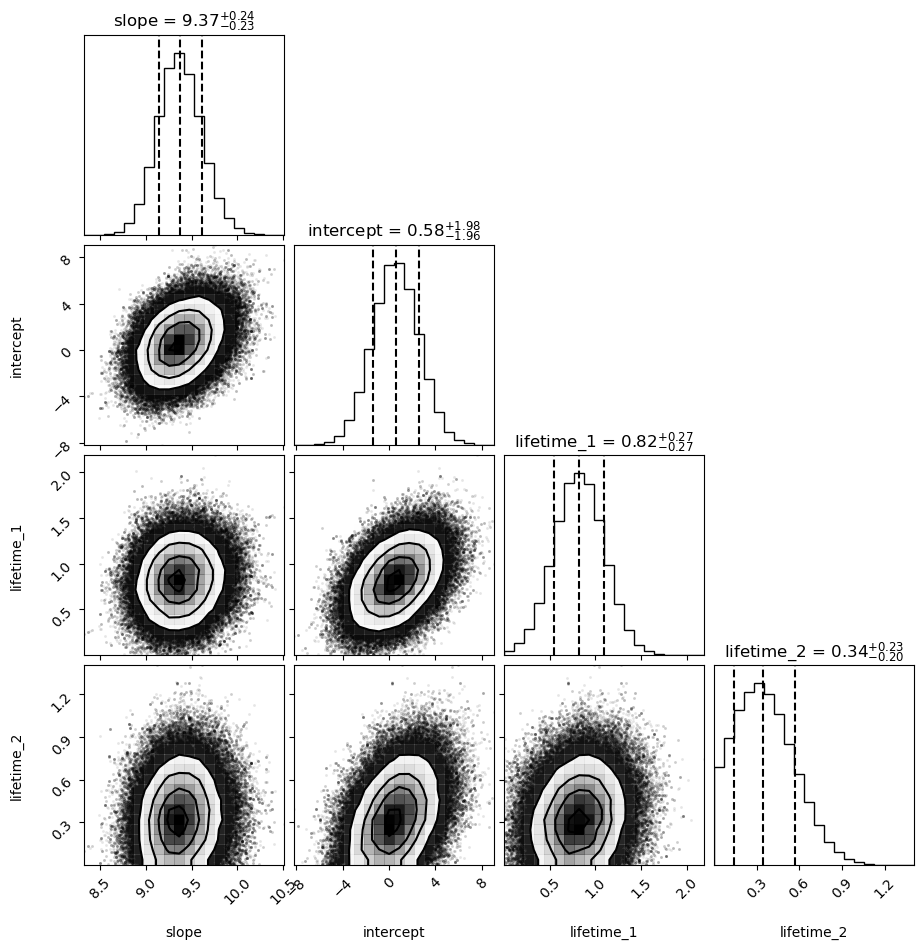

In [3]:
# Initial guess from curve_fit on literature data
popt_init, _ = curve_fit(linear_func, data_lit[:,0], data_lit[:,2], 
                          sigma=data_lit[:,3], absolute_sigma=True)

# Initialize walkers
n_walkers = 32
n_dim = n_params

# Starting positions: add small scatter around initial guess
pos = np.zeros((n_walkers, n_dim))
pos[:, 0] = popt_init[0] + 500 * np.random.randn(n_walkers)  # slope
pos[:, 1] = popt_init[1] + 2 * np.random.randn(n_walkers)    # intercept

# Initialize lifetimes from the linear prediction
for i in range(n_meas):
    beta = data_meas[i, 0]
    lifetime_init = 0#linear_func(beta, *popt_init)
    # Start with positive values
    if lifetime_init < 0:
        pos[:, 2+i] = np.random.normal(0,0.01, size=n_walkers)#5 * np.abs(np.random.randn(n_walkers))
    else:
        pos[:, 2+i] = lifetime_init + np.random.normal(0,0.01, size=n_walkers)#5 * np.abs(np.random.randn(n_walkers))

# Run MCMC
print(f"Running MCMC with {n_walkers} walkers, {n_dim} dimensions...")
sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_probability)

# Burn-in
n_burn = 2000
print(f"Burn-in: {n_burn} steps...")
state = sampler.run_mcmc(pos, n_burn, progress=True)

# Calculate the chi2 at the initial position to determine the scale factor for uncertainties
log_prob = sampler.get_log_prob(flat=True)
chain = sampler.get_chain( flat=True)
best_idx = np.argmax(log_prob)
best_params = chain[best_idx]
initial_chi2 = -2 * log_likelihood(best_params) / (len(data_lit) + n_meas - n_dim)
print(f"Initial chi2: {initial_chi2:.2f}")
scale_chi2 = 1 / initial_chi2

sampler.reset()

# Production run
n_steps = 10000
print(f"Production: {n_steps} steps...")
sampler.run_mcmc(state, n_steps, progress=True)

# Get samples
samples = sampler.get_chain(flat=True, thin=thin)

# Print autocorrelation time
try:
    tau = sampler.get_autocorr_time()
    print(f"Autocorrelation time: {tau}")
except emcee.autocorr.AutocorrError:
    print("Warning: Chain is too short to estimate autocorrelation time reliably.")

# Save the samples of last parameter to file
np.savetxt('results/lifetime_samples.txt', samples[:, 2:], comments='')

# Compute statistics
param_names = ['slope', 'intercept']
for i in range(n_meas):
    param_names.append(f'lifetime_{i+1}')

print("\n=== RESULTS ===")
for i, name in enumerate(param_names):
    mcmc = np.percentile(samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    if( i == 0 ):
        print(f"{name}: {1/mcmc[1]:.2f} + {q[1]:.2f} - {q[0]:.2f}")
    else:
        print(f"{name}: {mcmc[1]:.2f} + {q[1]:.2f} - {q[0]:.2f}")

# Get best-fit parameters (median)
coeffs = np.median(samples[:, :2], axis=0)
coeffs_err = np.std(samples[:, :2], axis=0)

lifetimes_best = np.median(samples[:, 2:], axis=0)
lifetimes_err = np.std(samples[:, 2:], axis=0)

# Find maximum likelihood sample
best_idx = np.argmax(sampler.get_log_prob(flat=True,thin=thin))
best_params = samples[best_idx]

print("\nBest-fit parameters (max likelihood):")
for i, name in enumerate(param_names):
    print(f"{name}: {best_params[i]:.2f}")

# Plot corner plot
hbar = 0.658212  # eV * fs
samples_plot = samples.copy()
samples_plot[:, 0] = 1 / samples_plot[:, 0] * 1e5  # Convert slope to stopping power
samples_plot[:, 1] *= 1e5

fig_corner = corner.corner(samples_plot, labels=param_names, 
                            quantiles=[0.16, 0.5, 0.84],
                            show_titles=True, 
                            title_kwargs={"fontsize": 12}
                            )
plt.savefig('plots/corner_plot.png', dpi=300)
plt.show()


Chi2 = 16.90, ndf = 17, Chi2/ndf = 0.99
Bin 4: center=0.13, dist=0.19 (within 1-sigma)
Bin 5: center=0.15, dist=0.17 (within 1-sigma)
Bin 6: center=0.18, dist=0.14 (within 1-sigma)
Bin 7: center=0.21, dist=0.11 (within 1-sigma)
Bin 8: center=0.24, dist=0.08 (within 1-sigma)
Bin 9: center=0.27, dist=0.05 (within 1-sigma)
Bin 10: center=0.30, dist=0.02 (within 1-sigma)
Bin 11: center=0.32, dist=0.00 (within 1-sigma)
Bin 12: center=0.35, dist=0.03 (within 1-sigma)
Bin 13: center=0.38, dist=0.06 (within 1-sigma)
Bin 14: center=0.41, dist=0.09 (within 1-sigma)
Bin 15: center=0.44, dist=0.12 (within 1-sigma)
Bin 16: center=0.46, dist=0.14 (within 1-sigma)
Bin 17: center=0.49, dist=0.17 (within 1-sigma)


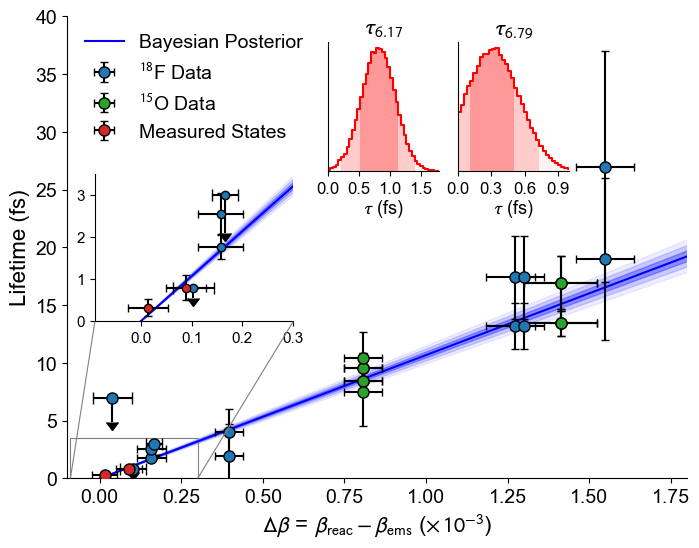

Literature: Beta=0.000397 ± 0.000043, Lifetime=4.00 ± 2.00 fs
Bayesian Prediction: 4.24 + 0.46 fs (68% CI)
Literature: Beta=0.000397 ± 0.000043, Lifetime=1.90 ± 2.80 fs
Bayesian Prediction: 4.24 + 0.46 fs (68% CI)
Literature: Beta=0.000158 ± 0.000045, Lifetime=1.77 ± 0.30 fs
Bayesian Prediction: 1.68 + 0.48 fs (68% CI)
Literature: Beta=0.000158 ± 0.000045, Lifetime=2.55 ± 0.50 fs
Bayesian Prediction: 1.68 + 0.48 fs (68% CI)
Literature: Beta=0.001548 ± 0.000088, Lifetime=19.00 ± 7.00 fs
Bayesian Prediction: 16.53 + 0.94 fs (68% CI)
Literature: Beta=0.001548 ± 0.000088, Lifetime=27.00 ± 10.00 fs
Bayesian Prediction: 16.53 + 0.94 fs (68% CI)
Literature: Beta=0.001274 ± 0.000089, Lifetime=13.20 ± 2.00 fs
Bayesian Prediction: 13.60 + 0.95 fs (68% CI)
Literature: Beta=0.001274 ± 0.000089, Lifetime=17.40 ± 3.60 fs
Bayesian Prediction: 13.60 + 0.95 fs (68% CI)
Literature: Beta=0.001299 ± 0.000033, Lifetime=13.20 ± 2.00 fs
Bayesian Prediction: 13.87 + 0.35 fs (68% CI)
Literature: Beta=0.001299 

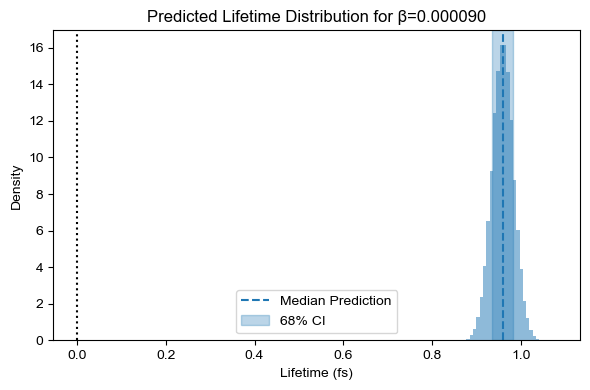

Measured: Beta=0.000015 ± 0.000039
Bayesian Prediction: 0.16 (+0.00 / -0.00) fs (68% CI)
  (Fraction physical: 320000/320000)


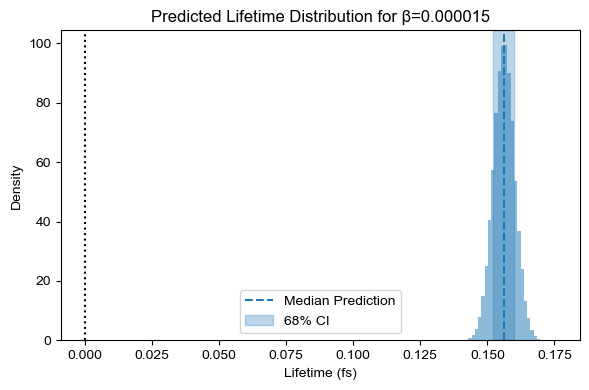

In [32]:
# ============= PLOTTING =============

# Nature-specific font settings
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "Liberation Sans"], # Fallback chain
    "pdf.fonttype": 42,        # Ensures text is editable in Illustrator/Inkscape
    "ps.fonttype": 42,
    "mathtext.fontset": "stixsans", # Makes LaTeX math match the sans-serif look
    "axes.labelweight": "normal",
    "axes.titleweight": "normal"
})

# --- Helper: smooth KDE-style gradient band ---
from scipy.stats import norm as _norm

def gradient_fill(ax, x, mu, sigma, color, n_strips=200, max_sigma=3.5, label=None):
    """
    Draw a smooth, continuously-fading uncertainty band that mimics a KDE.
    For each x the band assumes a Gaussian profile in y with width `sigma`.
    """
    # Build a fine vertical grid
    y_lo = (mu - max_sigma * sigma).min()
    y_hi = (mu + max_sigma * sigma).max()
    ny = 300
    y_grid = np.linspace(y_lo, y_hi, ny)

    # Evaluate the 2-D density image  (shape: ny × nx)
    # density[j, i] = Normal(y_grid[j] | mu[i], sigma[i])
    density = _norm.pdf(y_grid[:, None], loc=mu[None, :], scale=sigma[None, :])
    density /= density.max()  # normalise to [0, 1]

    # Convert the single colour into an RGBA image
    from matplotlib.colors import to_rgba
    rgba = np.array(to_rgba(color))
    max_alpha = 0.55  # peak opacity at the centre of the band
    img = np.zeros((*density.shape, 4))
    for c in range(3):
        img[:, :, c] = rgba[c]
    img[:, :, 3] = density * max_alpha

    extent = [x.min(), x.max(), y_lo, y_hi]
    ax.imshow(img, aspect='auto', extent=extent, origin='lower', zorder=1,
              interpolation='bilinear')

    # Invisible proxy artist for the legend
    if label is not None:
        ax.fill_between([], [], [], color=color, alpha=0.35, label=label)


# ---- scale factor: plot in units of 1e-3 ----
SF = 1e3  # multiply all Δβ values by this before plotting

fig, ax = plt.subplots(figsize=(8, 6))

# ---- Literature data ----
mask_ul     = data_lit[:-2, 3] == data_lit[:-2, 2]
mask_normal = ~mask_ul
mask_15o    = (data_lit[:, 4] == 1680) | (data_lit[:, 4] == 5180)

# 18F data
ax.errorbar(data_lit[:-2, 0][mask_normal] * SF,
            data_lit[:-2, 2][mask_normal],
            xerr=data_lit[:-2, 1][mask_normal] * SF,
            yerr=data_lit[:-2, 3][mask_normal],
            fmt='o', label='$^{18}$F Data', color='tab:blue', ecolor='black', markeredgecolor='black',
            capsize=3, zorder=10, markersize=8)

# 15O data
ax.errorbar(data_lit[:, 0][mask_15o] * SF,
            data_lit[:, 2][mask_15o],
            xerr=data_lit[:, 1][mask_15o] * SF,
            yerr=data_lit[:, 3][mask_15o],
            fmt='o', label='$^{15}$O Data', color='tab:green', ecolor='black', markeredgecolor='black',
            capsize=3, zorder=10, markersize=8)

# Upper limits
ax.errorbar(data_lit[:-2, 0][mask_ul] * SF,
            data_lit[:-2, 2][mask_ul],
            xerr=data_lit[:-2, 1][mask_ul] * SF,
            fmt='o', color='tab:blue',
            uplims=True, yerr=data_lit[:-2, 2][mask_ul] * 0.3, markeredgecolor='black',
            ecolor='black', capsize=4, zorder=10, markersize=8)

# ---- Bayesian posterior fit + KDE band ----
x_fit = np.linspace(-5e-4, 0.003, 200)

y_samples = []
for _ in range(500):
    idx = np.random.randint(len(samples))
    y_samples.append(samples[idx, 0] * x_fit + samples[idx, 1])
y_samples = np.array(y_samples)

y_fit = np.median(y_samples, axis=0)
y_fit_err = np.std(y_samples, axis=0)

ax.plot(x_fit * SF, y_fit, color='blue', zorder=5, label='Bayesian Posterior')
#gradient_fill(ax, x_fit * SF, y_fit, y_fit_err, color='blue')

# Plot filled region for the posterior uncertainty
ax.fill_between(x_fit * SF, y_fit - y_fit_err, y_fit + y_fit_err, color='blue', alpha=0.3)

# Plot 2 sigma
ax.fill_between(x_fit * SF, y_fit - 2*y_fit_err, y_fit + 2*y_fit_err, color='blue', alpha=0.15)

# Plot 3 sigma
ax.fill_between(x_fit * SF, y_fit - 3*y_fit_err, y_fit + 3*y_fit_err, color='blue', alpha=0.07)

# ---- Chi-squared calculation (posterior median vs literature + measured) ----
# Use the median slope and intercept from the posterior
slope_med  = np.median(samples[:, 0])
intercept_med = np.median(samples[:, 1])

# Collect all data points used in the fit (literature, excluding last 2 rows)
chi2_val = 0.0
npts = 0
for i in range(len(data_lit)):
    beta_i   = data_lit[i, 0]
    tau_i    = data_lit[i, 2]
    tau_err_i = data_lit[i, 3]
    is_upper = (tau_err_i == tau_i)  # upper-limit points
    if is_upper:
        pred_i = slope_med * beta_i + intercept_med
        if pred_i > tau_i:
            tot_err = np.sqrt(tau_err_i**2 + (slope_med * data_lit[i, 1])**2) / 1.42
            chi2_val += ((pred_i - tau_i) / tot_err) ** 2
        npts += 1
        continue  # skip upper limits in chi2
    pred_i = slope_med * beta_i + intercept_med
    tot_err = np.sqrt(tau_err_i**2 + (slope_med * data_lit[i, 1])**2) / 1.42
    chi2_val += ((tau_i - pred_i) / tot_err) ** 2
    npts += 1


# Also include measured states
#for i in range(len(data_meas)):
#    beta_i = data_meas[i, 0]
#    tau_i  = lifetimes_best[i]
#    tau_err_i = lifetimes_err[i]
#    if tau_err_i <= 0 or tau_i < tau_err_i * 2:
#        continue  # skip upper-limit-like points
#    pred_i = slope_med * beta_i + intercept_med
#    chi2_val += ((tau_i - pred_i) / tau_err_i) ** 2
#    npts += 1

ndof = npts - 2  # 2 free parameters: slope + intercept
chi2_ndf = chi2_val / ndof if ndof > 0 else np.nan
print(f'\nChi2 = {chi2_val:.2f}, ndf = {ndof}, Chi2/ndf = {chi2_ndf:.2f}')

# ---- Measured states ----        
ax.errorbar(1.463e-02, 0.32, xerr=3.923e-02, yerr=0.2,
                 fmt='o', color='tab:red', ecolor='black', label='Measured States',
                 capsize=3, zorder=10, markeredgecolor='black', markersize=8)

ax.errorbar(8.988e-02, 0.8, xerr=3.919e-02, yerr=0.3,
                 fmt='o', color='tab:red', ecolor='black',
                 capsize=3, zorder=10, markeredgecolor='black', markersize=8)
                

# ---- Simulation line + KDE band ----
popt_sim, pcov_sim = curve_fit(linear_func, sim[:, 1], sim[:, 0],
                               sigma=sim[:, 2], absolute_sigma=True)
grid = np.linspace(-5e-4, 0.003, 200)
#ax.plot(grid * SF, linear_func(grid, *popt_sim), color='black',
#        linestyle='--', label='Simulation', zorder=5)

slope_samples_sim = np.random.normal(popt_sim[0], stopping_power_err * abs(popt_sim[0]), 1000)
delta_beta_samples_sim = np.random.normal(0, beta_gain_err, 1000)
intercept_samples_sim = delta_beta_samples_sim * slope_samples_sim

sim_y_samples = np.array([linear_func(grid, s, ic)
                          for s, ic in zip(slope_samples_sim, intercept_samples_sim)])
sim_y_med = np.median(sim_y_samples, axis=0)
sim_y_std = np.std(sim_y_samples, axis=0)

#gradient_fill(ax, grid * SF, sim_y_med, sim_y_std, color='gray')

# ---- Axes formatting ----
ax.set_xlabel(r'$\Delta\beta$ = $\beta _{\mathrm{reac}} - \beta _{\mathrm{ems}}$ ($\times\,10^{-3}$)', fontsize=16)
ax.set_ylabel('Lifetime (fs)', fontsize=16)
ax.tick_params(axis='both', labelsize=14)
ax.set_xlim(-1e-4 * SF, 0.0018 * SF)   # → -0.1 … 1.8
ax.set_ylim(-1, 40)
#ax.axhline(0, color='black', linestyle=':')

# ---- Chi2 annotation ----
#ax.text(0.98, 0.97,
#        rf'$\chi^2 / \mathrm{{ndf}} = {chi2_val:.1f}\,/\,{ndof} = {chi2_ndf:.2f}$',
#        transform=ax.transAxes, fontsize=13, va='top', ha='right',
#        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray'))

# ---- Inset histograms for τ_6.17 and τ_6.79 ----
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.stats import gaussian_kde

tau_617_samples = samples[:, 2]
tau_679_samples = samples[:, 3]

# --- Inset 1: τ_6.17 (left of the pair) ---
ax_in1 = inset_axes(ax, width='18%', height='28%',
                    loc='upper center', borderpad=1.5,
                    bbox_to_anchor=(0.01, -0.01, 1, 1), bbox_transform=ax.transAxes)

# Histogram
n, bins, patches = ax_in1.hist(tau_617_samples, bins=50, density=True, color='red', alpha=0.0)

# Apply shading based on sigma regions
mu, sigma = 0.82, 0.3
for i in range(len(patches)):
    bin_center = (bins[i] + bins[i+1]) / 2
    dist = abs(bin_center - mu)
    
    if dist <= sigma:
        # 1-sigma region: Stronger color
        patches[i].set_alpha(0.4)
    elif dist <= 2 * sigma:
        # 2-sigma region: Medium color
        patches[i].set_alpha(0.2)
    else:
        # Outside 2-sigma: Faint color
        patches[i].set_alpha(0.05)

# Plot the contour of the histogram as a step line
bin_centers1 = 0.5 * (bins[:-1] + bins[1:])
ax_in1.step(bin_centers1, n, where='mid', color='red', lw=1.5)

ax_in1.set_title(r'$\tau_{6.17}$', fontsize=16, pad=6)
ax_in1.set_xlabel(r'$\tau$ (fs)', fontsize=13, labelpad=1)
ax_in1.set_ylabel('')
ax_in1.tick_params(labelsize=12)
ax_in1.set_yticks([])
ax_in1.set_xlim(0.0, 1.8)
ax_in1.set_xticks([0.0, 0.5, 1.0, 1.5])

# --- Inset 2: τ_6.79 (right of the pair) ---
ax_in2 = inset_axes(ax, width='18%', height='28%',
                    loc='upper center', borderpad=1.5,
                    bbox_to_anchor=(0.22, -0.01, 1, 1), bbox_transform=ax.transAxes)

# Histogram
n, bins, patches = ax_in2.hist(tau_679_samples, bins=50, density=True, color='red', alpha=0.0)

# Apply shading based on sigma regions
mu, sigma = 0.32, 0.2
for i in range(len(patches)):
    bin_center = (bins[i] + bins[i+1]) / 2
    dist = abs(bin_center - mu)
    
    if dist <= sigma:
        # 1-sigma region: Stronger color
        print(f"Bin {i}: center={bin_center:.2f}, dist={dist:.2f} (within 1-sigma)")
        patches[i].set_alpha(0.4)
    elif dist <= 2 * sigma:
        # 2-sigma region: Medium color
        patches[i].set_alpha(0.2)
    else:
        # Outside 2-sigma: Faint color
        patches[i].set_alpha(0.05)

# Plot the contour of the histogram as a step line
bin_centers2 = 0.5 * (bins[:-1] + bins[1:])
ax_in2.step(bin_centers2, n, where='mid', color='red', lw=1.5)

#ax_in2.set_yscale('log')
ax_in2.set_title(r'$\tau_{6.79}$', fontsize=16, pad=6)
ax_in2.set_xlabel(r'$\tau$ (fs)', fontsize=13, labelpad=1)
ax_in2.set_ylabel('')
ax_in2.tick_params(labelsize=12)
ax_in2.set_yticks([])
ax_in2.set_xlim(0, 1.0)
# xticks at 0.1, 0.3, 0.5
ax_in2.set_xticks([0.0, 0.3, 0.6, 0.9])

## ---- Legend (after insets so it doesn't get occluded) ----
ax.legend(fontsize=14, ncol=1, loc='upper left', frameon=False, edgecolor='gray', facecolor='white', framealpha=0.8)

# Remove upper and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Also for the insets
for ax_in in [ax_in1, ax_in2]:
    ax_in.spines['top'].set_visible(False)
    ax_in.spines['right'].set_visible(False)

ax.set_ylim(0, 40)

# ---- Inset: zoom into low-Δβ, low-τ region ----
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

ax_zoom = inset_axes(ax, width='32%', height='32%',
                     loc='center left', borderpad=2.0)

# Bayesian posterior median + bands
ax_zoom.plot(x_fit * SF, y_fit, color='blue', zorder=5)
ax_zoom.fill_between(x_fit * SF, y_fit - y_fit_err,     y_fit + y_fit_err,     color='blue', alpha=0.30)
ax_zoom.fill_between(x_fit * SF, y_fit - 2*y_fit_err,   y_fit + 2*y_fit_err,   color='blue', alpha=0.15)
ax_zoom.fill_between(x_fit * SF, y_fit - 3*y_fit_err,   y_fit + 3*y_fit_err,   color='blue', alpha=0.07)

# 18F literature points (normal)
ax_zoom.errorbar(data_lit[:-2, 0][mask_normal] * SF,
                 data_lit[:-2, 2][mask_normal],
                 xerr=data_lit[:-2, 1][mask_normal] * SF,
                 yerr=data_lit[:-2, 3][mask_normal],
                 fmt='o', color='tab:blue', ecolor='black',
                 markeredgecolor='black', capsize=3, zorder=10, markersize=6)

# 18F upper limits
ax_zoom.errorbar(data_lit[:-2, 0][mask_ul] * SF,
                 data_lit[:-2, 2][mask_ul],
                 xerr=data_lit[:-2, 1][mask_ul] * SF,
                 fmt='o', color='tab:blue',
                 uplims=True, yerr=data_lit[:-2, 2][mask_ul] * 0.3,
                 ecolor='black', capsize=4, zorder=10,
                 markeredgecolor='black', markersize=6)

# 15O literature
ax_zoom.errorbar(data_lit[:, 0][mask_15o] * SF,
                 data_lit[:, 2][mask_15o],
                 xerr=data_lit[:, 1][mask_15o] * SF,
                 yerr=data_lit[:, 3][mask_15o],
                 fmt='o', color='tab:green', ecolor='black',
                 markeredgecolor='black', capsize=3, zorder=10, markersize=6)

ax_zoom.errorbar(1.463e-02, 0.32, xerr=3.923e-02, yerr=0.2,
                 fmt='o', color='tab:red', ecolor='black',
                 capsize=3, zorder=10, markeredgecolor='black', markersize=6)

ax_zoom.errorbar(8.988e-02, 0.8, xerr=3.919e-02, yerr=0.3,
                 fmt='o', color='tab:red', ecolor='black',
                 capsize=3, zorder=10, markeredgecolor='black', markersize=6)

# Zoom limits: x in [0, 1e-4] → [0, 0.1] after SF; y in [0, 1.5]
ax_zoom.set_xlim(-0.09, 0.3)
ax_zoom.set_ylim(0, 3.5)
ax_zoom.tick_params(labelsize=11)
ax_zoom.spines['top'].set_visible(False)
ax_zoom.spines['right'].set_visible(False)

# Connector lines from main axes to the inset
mark_inset(ax, ax_zoom, loc1=3, loc2=4, fc='none', ec='gray', lw=0.8, zorder=4)

fig.savefig('plots/beta_lifetime_fit.pdf', bbox_inches='tight')
plt.show()

# ---- Bayesian posterior predictions vs literature ----
for i in range(len(data_lit) - 2):
    beta = data_lit[i, 0]
    beta_err = data_lit[i, 1]
    lifetime_lit = data_lit[i, 2]
    lifetime_lit_err = data_lit[i, 3]

    predicted_lifetimes = samples[:, 0] * beta + samples[:, 1]
    predicted_lifetimes_lower = samples[:, 0] * (beta - beta_err) + samples[:, 1]

    pred_median = np.median(predicted_lifetimes)
    pred_lower = np.median(predicted_lifetimes_lower)
    pred_sigma = np.abs(pred_median - pred_lower)

    print(f'Literature: Beta={beta:.6f} ± {beta_err:.6f}, '
          f'Lifetime={lifetime_lit:.2f} ± {lifetime_lit_err:.2f} fs')
    print(f'Bayesian Prediction: {pred_median:.2f} + {pred_sigma:.2f} fs (68% CI)')

for i in range(len(data_meas)):
    beta = data_meas[i, 0]
    beta_err = data_meas[i, 1]

    predicted_lifetimes = samples[:, 0] * beta + samples[:, 1]

    # Enforce physical constraint: τ > 0
    physical_mask = predicted_lifetimes > 0
    pred_physical = predicted_lifetimes[physical_mask]

    # Percentile-based CI from the truncated distribution
    pred_median = np.median(pred_physical)
    pred_lo, pred_hi = np.percentile(pred_physical, [16, 84])

    print(f'Measured: Beta={beta:.6f} ± {beta_err:.6f}')
    print(f'Bayesian Prediction: {pred_median:.2f} (+{pred_hi - pred_median:.2f} / -{pred_median - pred_lo:.2f}) fs (68% CI)')
    print(f'  (Fraction physical: {physical_mask.sum()}/{len(predicted_lifetimes)})')

    # Plot a distribution of predictions for this beta value
    plt.figure(figsize=(6, 4))
    plt.hist(predicted_lifetimes, bins=30, density=True, alpha=0.5, color='tab:blue')
    plt.axvline(pred_median, color='tab:blue', linestyle='--', label='Median Prediction')
    plt.axvspan(pred_lo, pred_hi, color='tab:blue', alpha=0.3, label='68% CI')
    plt.axvline(0, color='black', linestyle=':')
    plt.title(f'Predicted Lifetime Distribution for β={beta:.6f}')
    plt.xlabel('Lifetime (fs)')
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    plt.show()